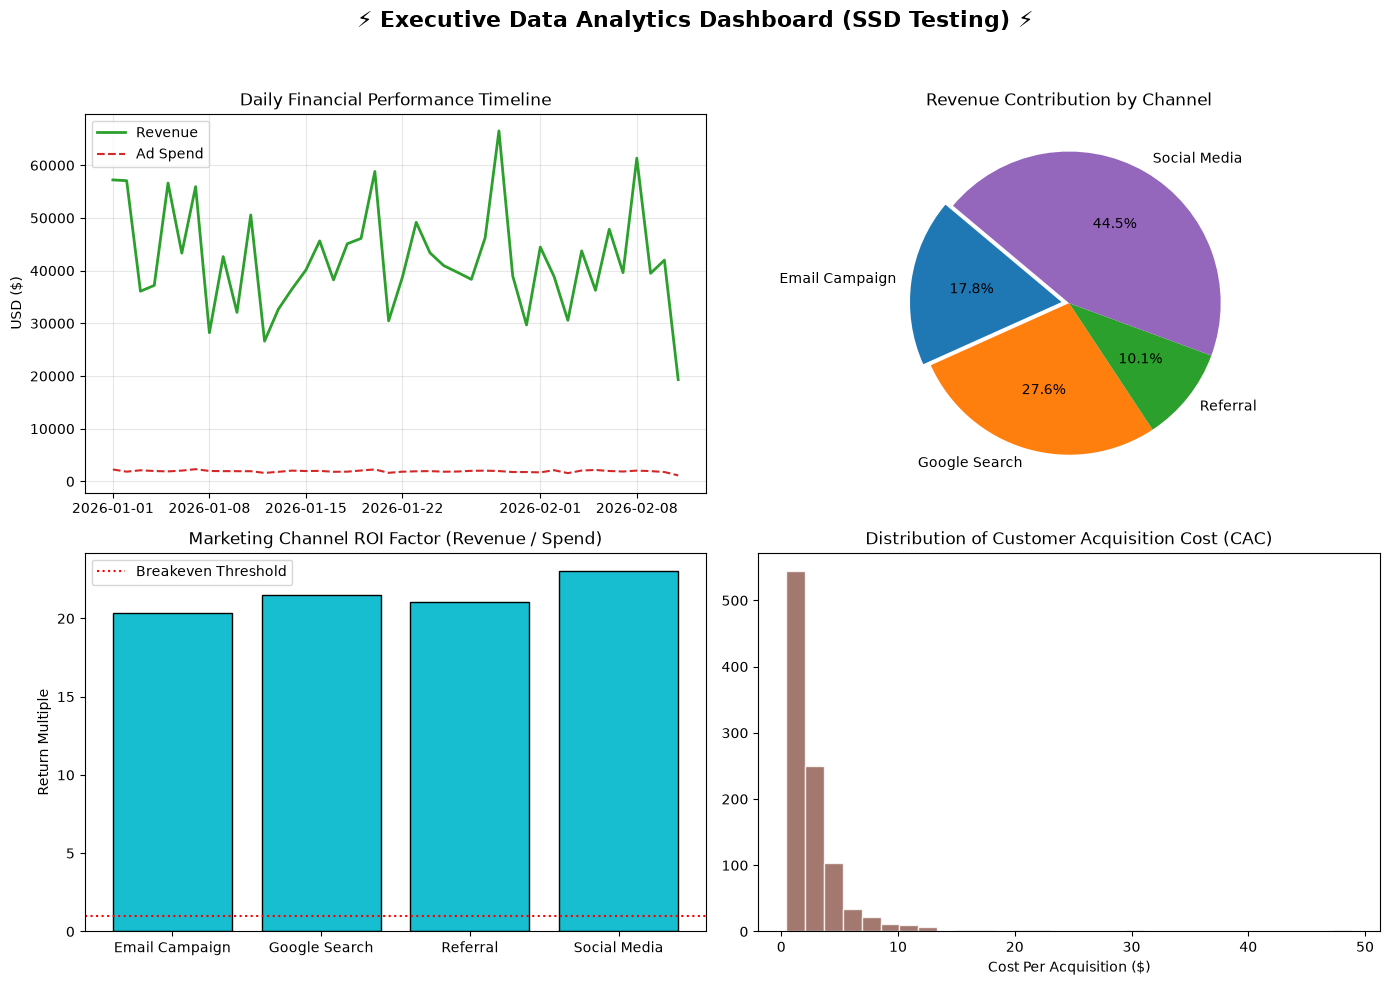

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a complex mock Data Analytics Dataset (1,000 transactions)
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=1000, freq="h") # Fix: Lowercase 'h' for modern Pandas
channels = ["Social Media", "Google Search", "Email Campaign", "Referral"]

df = pd.DataFrame({
    "Timestamp": dates,
    "Marketing_Channel": np.random.choice(channels, size=1000, p=[0.4, 0.3, 0.2, 0.1]),
    "Ad_Spend_USD": np.random.uniform(10, 150, size=1000),
    "Conversion_Rate": np.random.beta(a=2, b=5, size=1000)
})

# Engineer downstream analytical metrics
df["Calculated_Signups"] = np.round(df["Ad_Spend_USD"] * df["Conversion_Rate"] * np.random.uniform(1, 3, size=1000))
df["Revenue_USD"] = df["Calculated_Signups"] * np.random.choice([25, 50, 100], size=1000, p=[0.6, 0.3, 0.1]) # Fix: Completed choice matrix

# 2. Perform Data Aggregations (The Analytics Engine)
channel_perf = df.groupby("Marketing_Channel").agg(
    Total_Spend=("Ad_Spend_USD", "sum"),
    Total_Revenue=("Revenue_USD", "sum"),
    Total_Signups=("Calculated_Signups", "sum")
).reset_index()
channel_perf["ROI_Factor"] = channel_perf["Total_Revenue"] / channel_perf["Total_Spend"]

time_perf = df.set_index("Timestamp").resample("D")[["Revenue_USD", "Ad_Spend_USD"]].sum()

# 3. Render the Multi-Plot Executive Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("⚡ Executive Data Analytics Dashboard (SSD Testing) ⚡", fontsize=16, fontweight="bold")

# Plot A: Revenue vs Spend Timeline (Line Chart)
axes[0, 0].plot(time_perf.index, time_perf["Revenue_USD"], label="Revenue", color="#2ca02c", lw=2)
axes[0, 0].plot(time_perf.index, time_perf["Ad_Spend_USD"], label="Ad Spend", color="#d62728", lw=1.5, linestyle="--")
axes[0, 0].set_title("Daily Financial Performance Timeline", fontsize=12)
axes[0, 0].set_ylabel("USD ($)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot B: Revenue Share by Acquisition Channel (Pie Chart)
axes[0, 1].pie(channel_perf["Total_Revenue"], labels=channel_perf["Marketing_Channel"], autopct="%1.1f%%", 
               colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"], startangle=140, explode=(0.05, 0, 0, 0))
axes[0, 1].set_title("Revenue Contribution by Channel", fontsize=12)

# Plot C: Ad Spend vs ROI Efficiency (Bar Chart)
axes[1, 0].bar(channel_perf["Marketing_Channel"], channel_perf["ROI_Factor"], color="#17becf", edgecolor="black")
axes[1, 0].axhline(1.0, color="red", linestyle=":", label="Breakeven Threshold")
axes[1, 0].set_title("Marketing Channel ROI Factor (Revenue / Spend)", fontsize=12)
axes[1, 0].set_ylabel("Return Multiple")
axes[1, 0].legend()

# Plot D: Customer Acquisition Cost Distribution (Histogram)
df["CAC"] = df["Ad_Spend_USD"] / (df["Calculated_Signups"] + 1) # avoid division by zero
axes[1, 1].hist(df["CAC"], bins=30, color="#8c564b", alpha=0.8, edgecolor="white")
axes[1, 1].set_title("Distribution of Customer Acquisition Cost (CAC)", fontsize=12)
axes[1, 1].set_xlabel("Cost Per Acquisition ($)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


